<a href="https://colab.research.google.com/github/likhith-kumarn/Data_Science/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv('wine.csv')
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [2]:
df.shape

(178, 14)

In [3]:
df.columns

Index(['Type', 'Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols',
       'Flavanoids', 'Nonflavanoids', 'Proanthocyanins', 'Color', 'Hue',
       'Dilution', 'Proline'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [5]:
df.isnull().sum()

,0
Type,0
Alcohol,0
Malic,0
Ash,0
Alcalinity,0
Magnesium,0
Phenols,0
Flavanoids,0
Nonflavanoids,0
Proanthocyanins,0


In [6]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [7]:
df.nunique()

,0
Type,3
Alcohol,126
Malic,133
Ash,79
Alcalinity,63
Magnesium,53
Phenols,97
Flavanoids,132
Nonflavanoids,39
Proanthocyanins,101


In [8]:
df.nunique().sum()

np.int64(1279)

In [9]:
df.value_counts().sum()

np.int64(178)

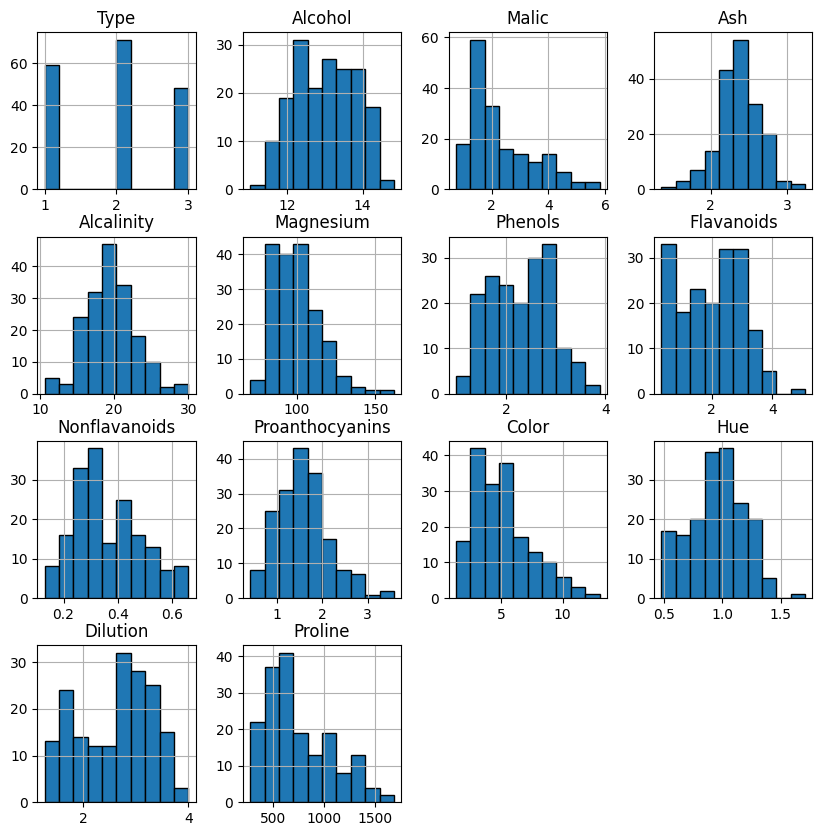

In [14]:
import matplotlib.pyplot as plt
df.hist(figsize=(10,10),bins=10,edgecolor='black')
plt.show()

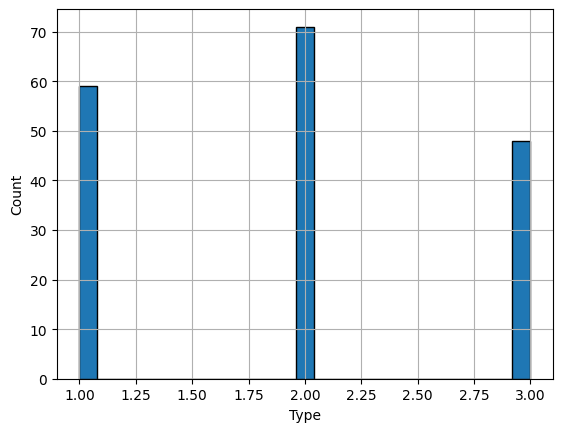

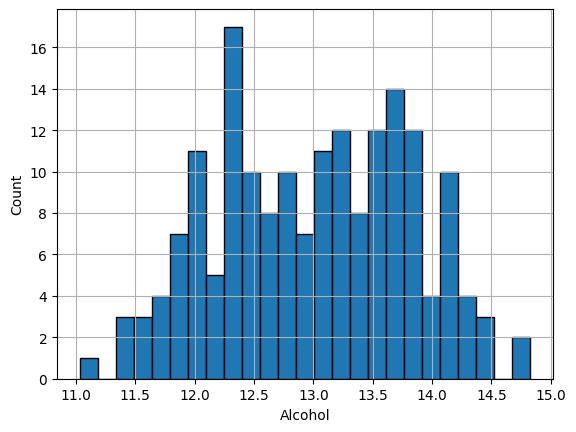

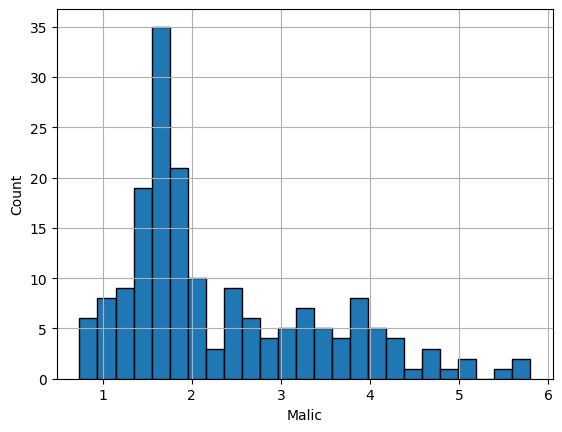

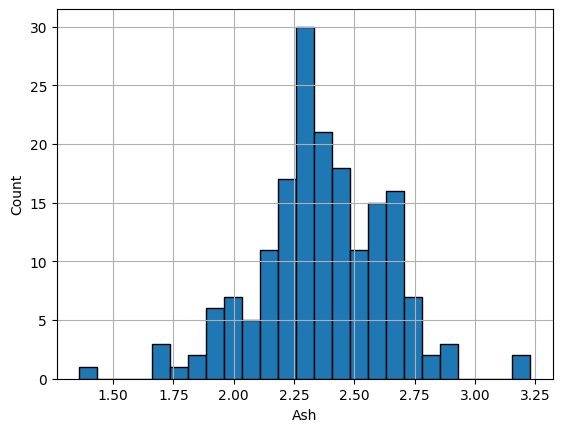

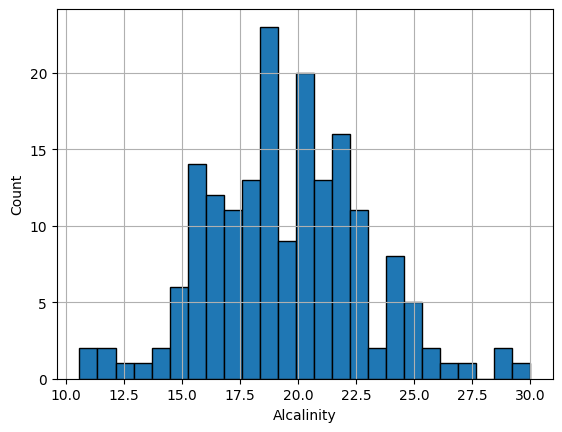

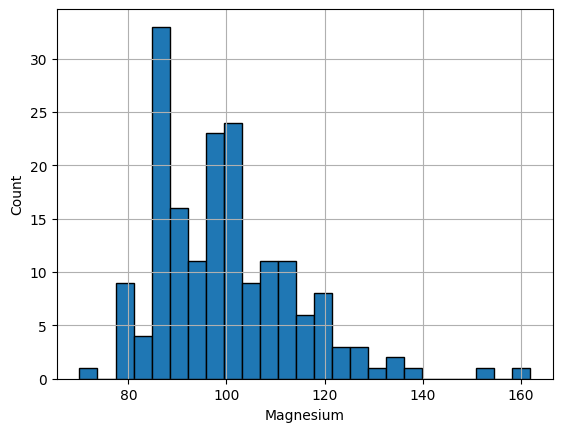

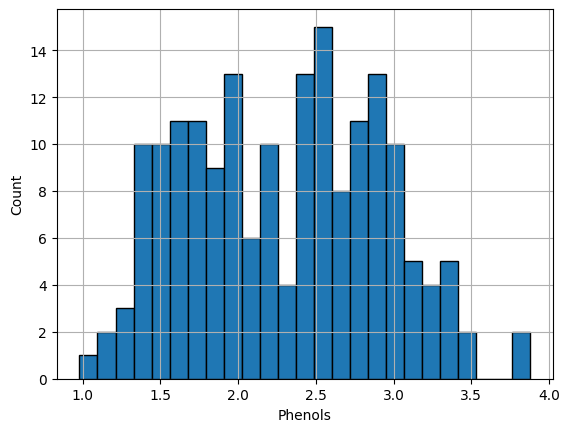

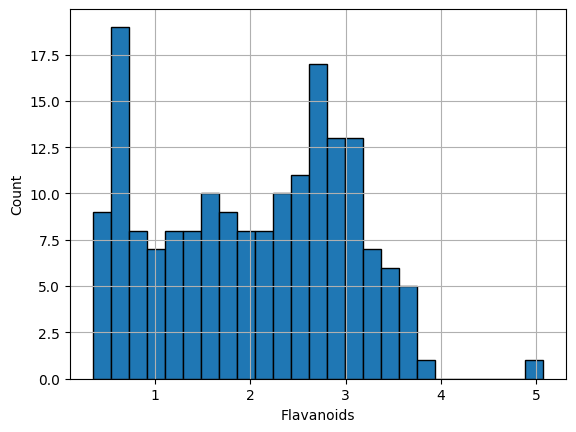

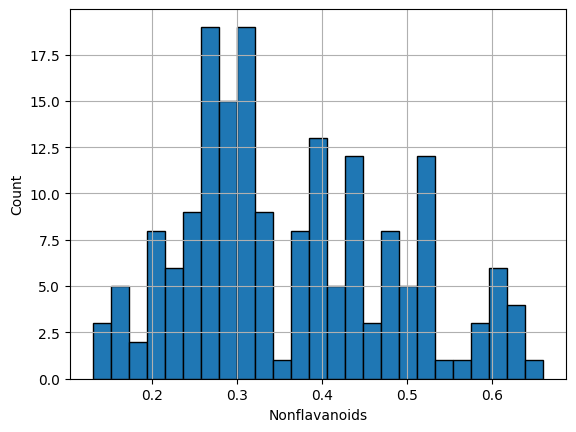

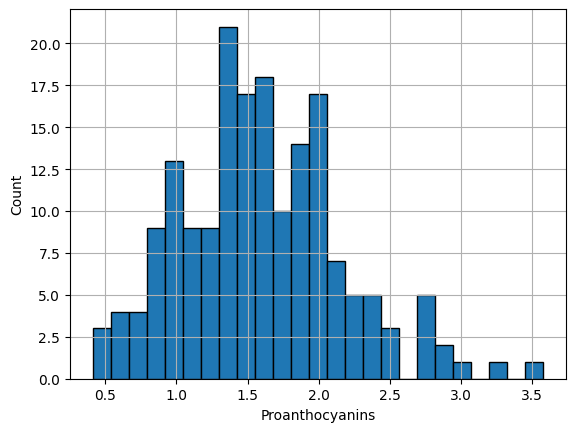

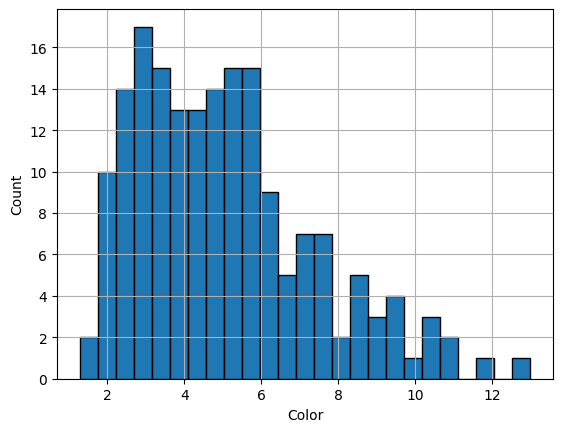

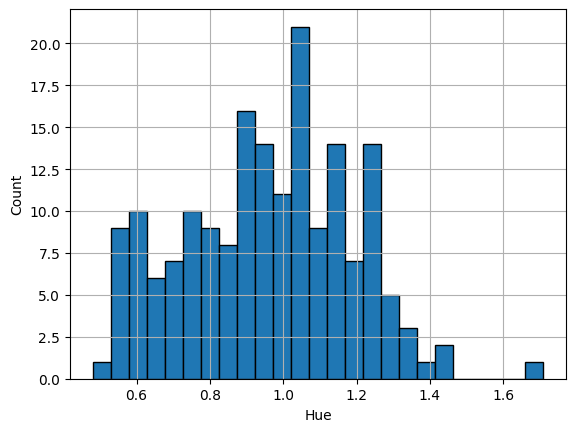

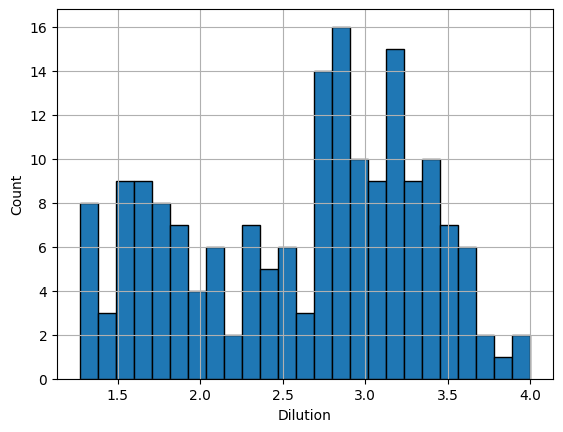

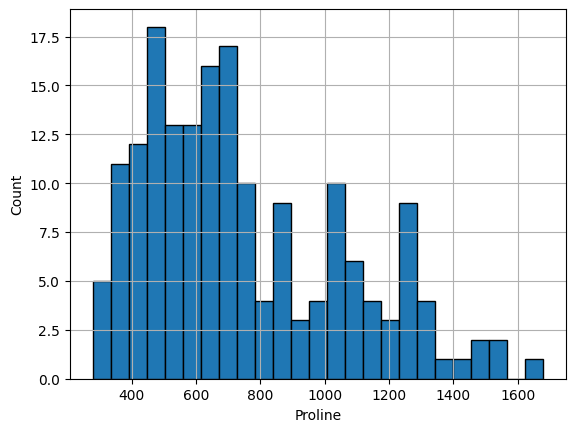

In [15]:
for feature in df.columns:
    df=df.copy()
    df[feature].hist(bins=25, edgecolor="Black")
    plt.ylabel("Count")
    plt.xlabel(feature)
    plt.show()

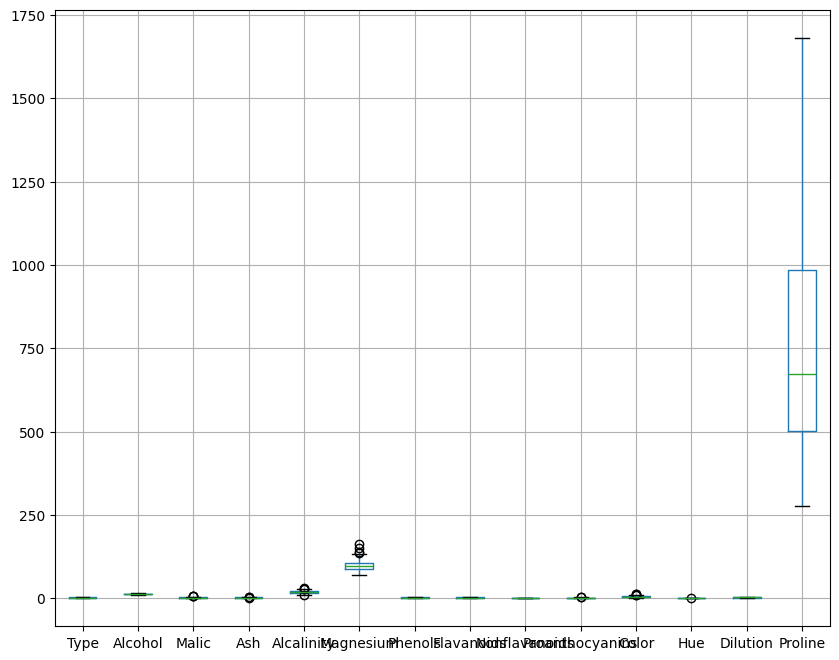

In [16]:
df.boxplot(figsize=(10,8))
plt.show()

<Axes: >

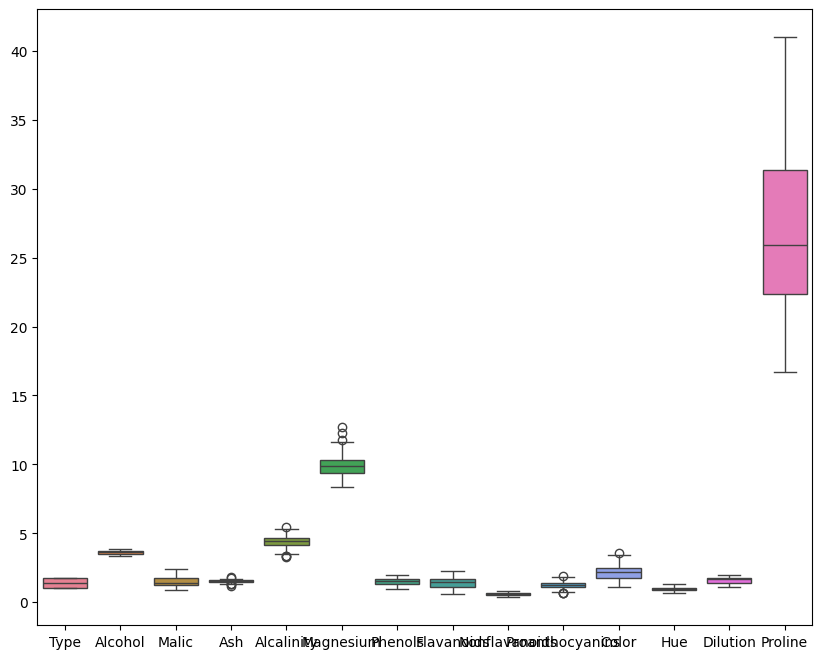

In [18]:
import seaborn as sns
plt.figure(figsize=(10,8))
sns.boxplot(data=np.sqrt(df))

In [20]:
z=df.corr()
z.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
Type,1.000000,-0.328222,0.437776,-0.049643,0.517859,-0.209179,-0.719163,-0.847498,0.489109,-0.499130,0.265668,-0.617369,-0.788230,-0.633717
Alcohol,-0.328222,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720
Malic,0.437776,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011
Ash,-0.049643,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626
Alcalinity,0.517859,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597


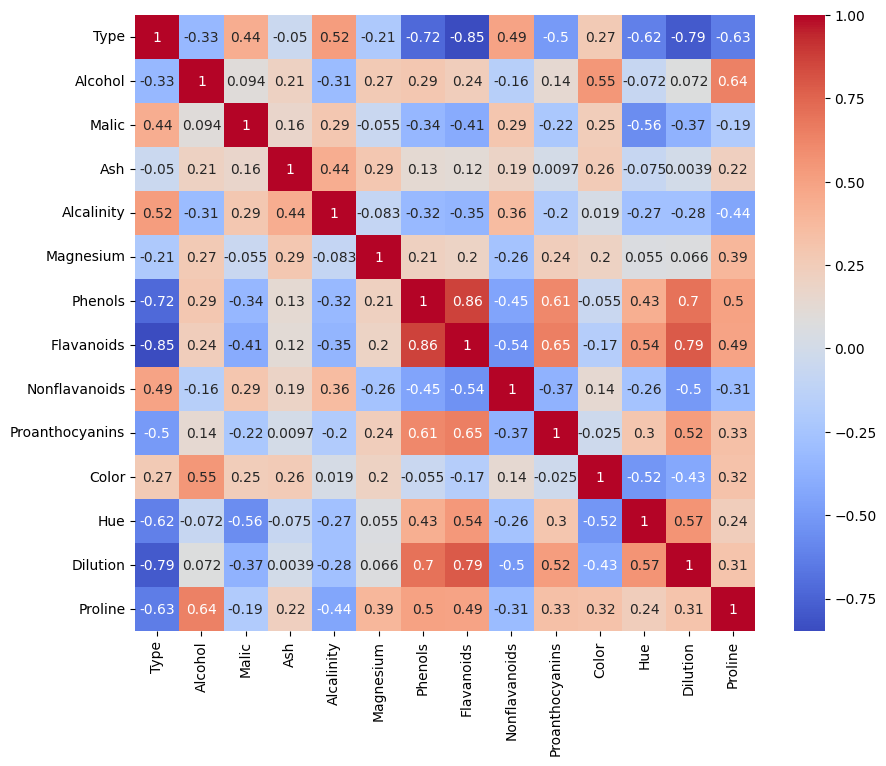

In [21]:
plt.figure(figsize=(10, 8))
sns.heatmap(z,annot=True,cmap="coolwarm")
plt.show()

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [23]:
pca = PCA()
pca_data = pca.fit_transform(scaled_data)


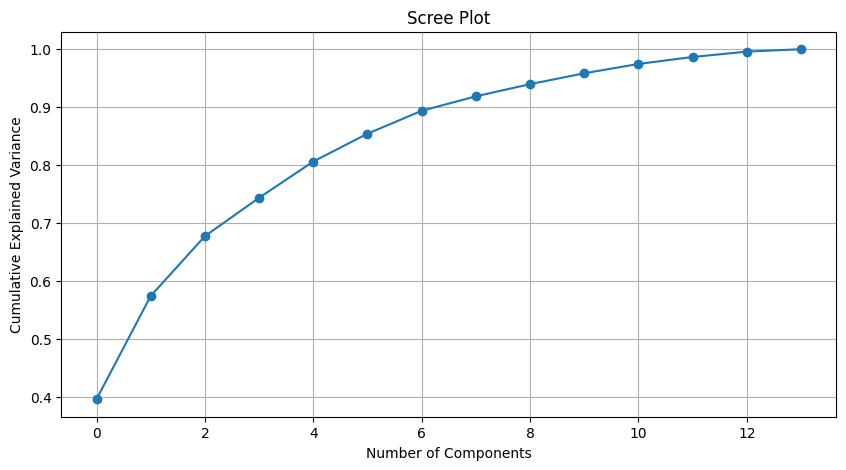

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot')
plt.grid(True)
plt.show()

In [25]:
# Choose first N components
n_components = 2  # Example, choose based on scree plot
pca_final = PCA(n_components=n_components)
pca_scaled_data = pca_final.fit_transform(scaled_data)


In [26]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
k= 3
KMeans = KMeans(n_clusters=k, random_state=42)
orig_labels = KMeans.fit_predict(scaled_data)


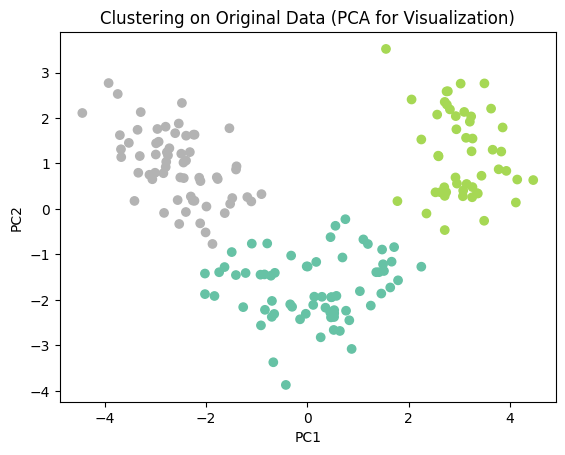

In [27]:
#Visualize Clusters (Using PCA for 2D projection)
pca_2d = PCA(n_components=2)
orig_2d = pca_2d.fit_transform(scaled_data)

plt.scatter(orig_2d[:, 0], orig_2d[:, 1], c=orig_labels, cmap='Set2')
plt.title("Clustering on Original Data (PCA for Visualization)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [28]:
#Evaluate Clustering
print("Silhouette Score (Original):", silhouette_score(scaled_data, orig_labels))
print("Davies-Bouldin Index (Original):", davies_bouldin_score(scaled_data, orig_labels))


Silhouette Score (Original): 0.30648398324833453
Davies-Bouldin Index (Original): 1.315707552261773


In [29]:
#Clustering on PCA-Transformed Data
# Apply K-Means to PCA data
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
KMeans_pca = KMeans(n_clusters=k, random_state=42)
pca_labels = KMeans_pca.fit_predict(pca_scaled_data)


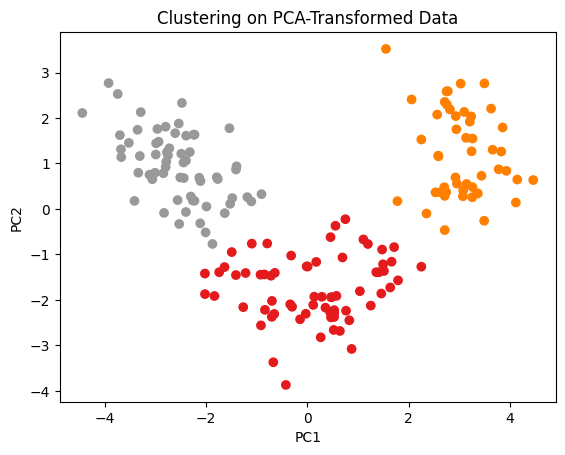

In [30]:
#Visualize
plt.scatter(pca_scaled_data[:, 0], pca_scaled_data[:, 1], c=pca_labels, cmap='Set1')
plt.title("Clustering on PCA-Transformed Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [31]:
# Evaluate
print("Silhouette Score (PCA):", silhouette_score(pca_scaled_data, pca_labels))
print("Davies-Bouldin Index (PCA):", davies_bouldin_score(pca_scaled_data, pca_labels))


Silhouette Score (PCA): 0.6024415520362845
Davies-Bouldin Index (PCA): 0.5397078562575713
